<a href="https://colab.research.google.com/github/asr7code/crop_recommendation_onrender/blob/main/Crop_Recommendation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Recommendation System
### ML Classification Model — Training & Export

**Features:** N, P, K, Temperature, Humidity, pH, Rainfall  
**Target:** Crop Label (22 classes)  
**Goal:** Train the best classifier and export it for deployment


##Install & Import Libraries

In [ ]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


##Load & Explore Dataset

In [ ]:
# Load dataset
URL = 'https://raw.githubusercontent.com/asr7code/crpdataset/refs/heads/main/crop_recommendation.csv'
df = pd.read_csv(URL)

print(f'Dataset Shape: {df.shape}')
print(f'Unique Crops: {df["label"].nunique()}')
print(f'\nCrop Classes:\n{sorted(df["label"].unique())}')
df.head()

Dataset Shape: (2200, 8)
Unique Crops: 22

Crop Classes:
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# Dataset info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Statistical Summary ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


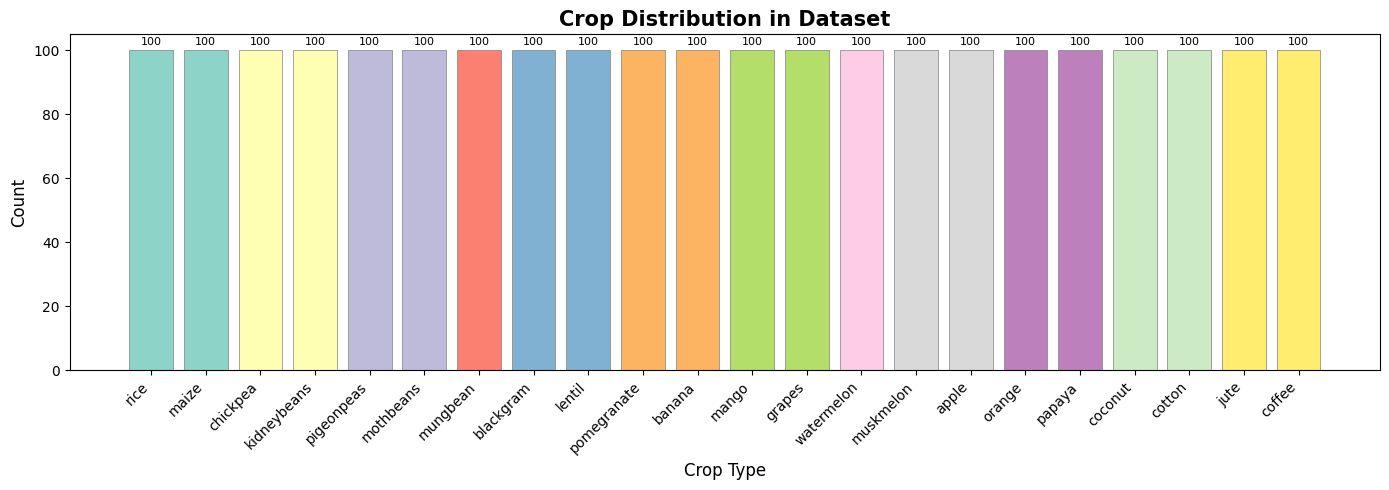

In [ ]:
# Class distribution
plt.figure(figsize=(14, 5))
crop_counts = df['label'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(crop_counts)))
bars = plt.bar(crop_counts.index, crop_counts.values, color=colors, edgecolor='gray', linewidth=0.5)
plt.title('Crop Distribution in Dataset', fontsize=15, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, crop_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('crop_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

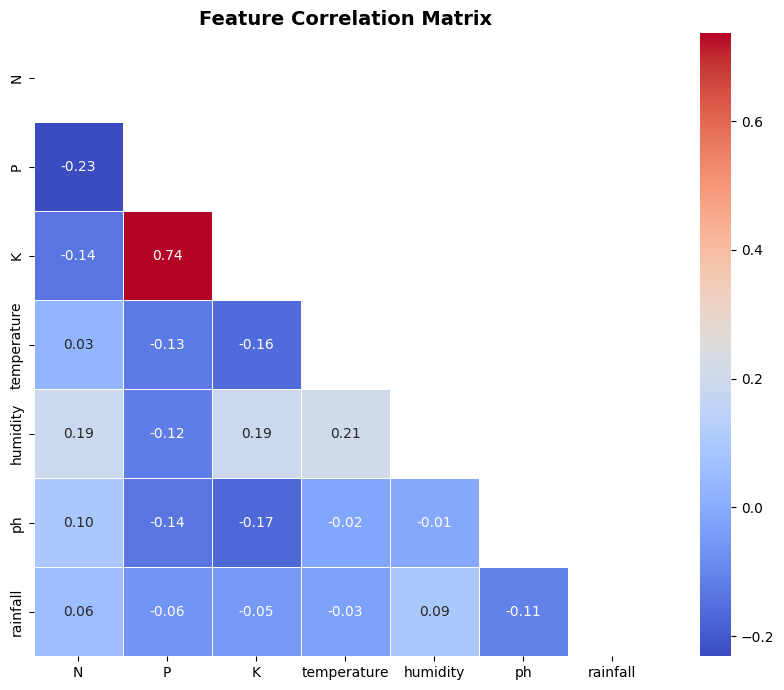

In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(9, 7))
corr = df.drop('label', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

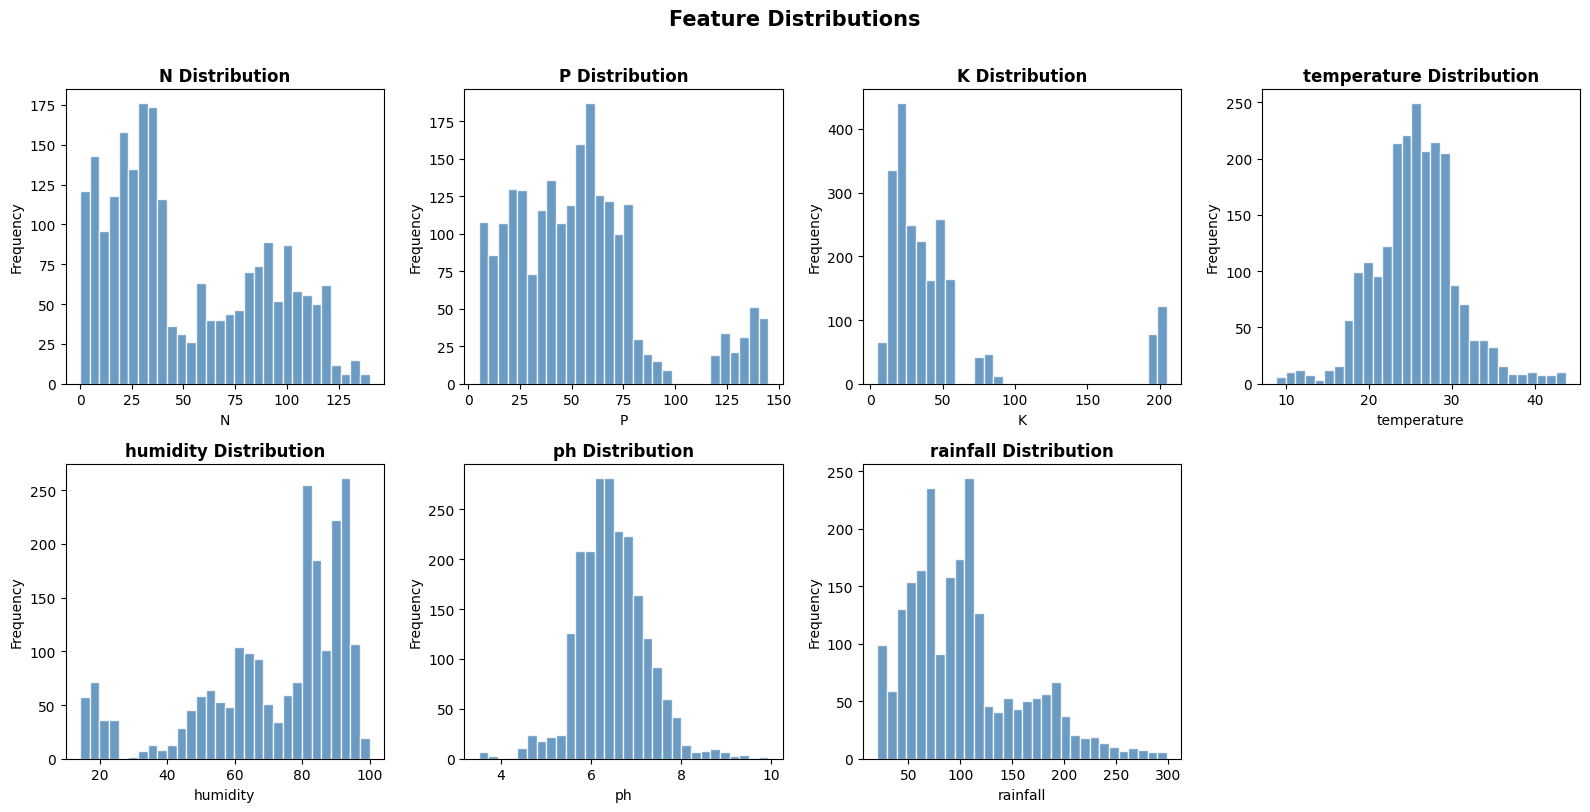

In [ ]:
# Feature distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

##Data Preprocessing

In [ ]:
# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Save label mapping
label_mapping = {int(enc): name for enc, name in zip(le.transform(le.classes_), le.classes_)}
print('Label Mapping:')
for k, v in sorted(label_mapping.items()):
    print(f'  {k:2d} → {v}')

Label Mapping:
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute
   9 → kidneybeans
  10 → lentil
  11 → maize
  12 → mango
  13 → mothbeans
  14 → mungbean
  15 → muskmelon
  16 → orange
  17 → papaya
  18 → pigeonpeas
  19 → pomegranate
  20 → rice
  21 → watermelon


In [ ]:
# Feature matrix and target
X = df[features]
y = df['label_encoded']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 1760 | Test size: 440


##Train & Compare Multiple Models

In [ ]:
# Define all models to compare
models = {
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':            SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes':          GaussianNB(),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
}

results = {}

print('Training all models...\n')
print(f'{"Model":<25} {"Train Acc":>10} {"Test Acc":>10} {"CV Mean":>10} {"CV Std":>8}')
print('─' * 65)

for name, model in models.items():
    # Use scaled data for SVM, KNN, LR, NB; raw for tree-based
    if name in ['SVM (RBF)', 'K-Nearest Neighbors', 'Logistic Regression', 'Naive Bayes']:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'scaled': name in ['SVM (RBF)', 'K-Nearest Neighbors', 'Logistic Regression', 'Naive Bayes']
    }

    print(f'{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}')

print('\nAll models trained!')

Training all models...

Model                      Train Acc   Test Acc    CV Mean   CV Std
─────────────────────────────────────────────────────────────────
Random Forest                 1.0000     0.9955     0.9943   0.0054
Extra Trees                   1.0000     0.9955     0.9926   0.0050
Gradient Boosting             1.0000     0.9886     0.9852   0.0071
Decision Tree                 1.0000     0.9795     0.9852   0.0075
K-Nearest Neighbors           0.9847     0.9795     0.9653   0.0075
SVM (RBF)                     0.9858     0.9841     0.9761   0.0075
Naive Bayes                   0.9949     0.9955     0.9943   0.0051
Logistic Regression           0.9739     0.9727     0.9676   0.0113

All models trained!


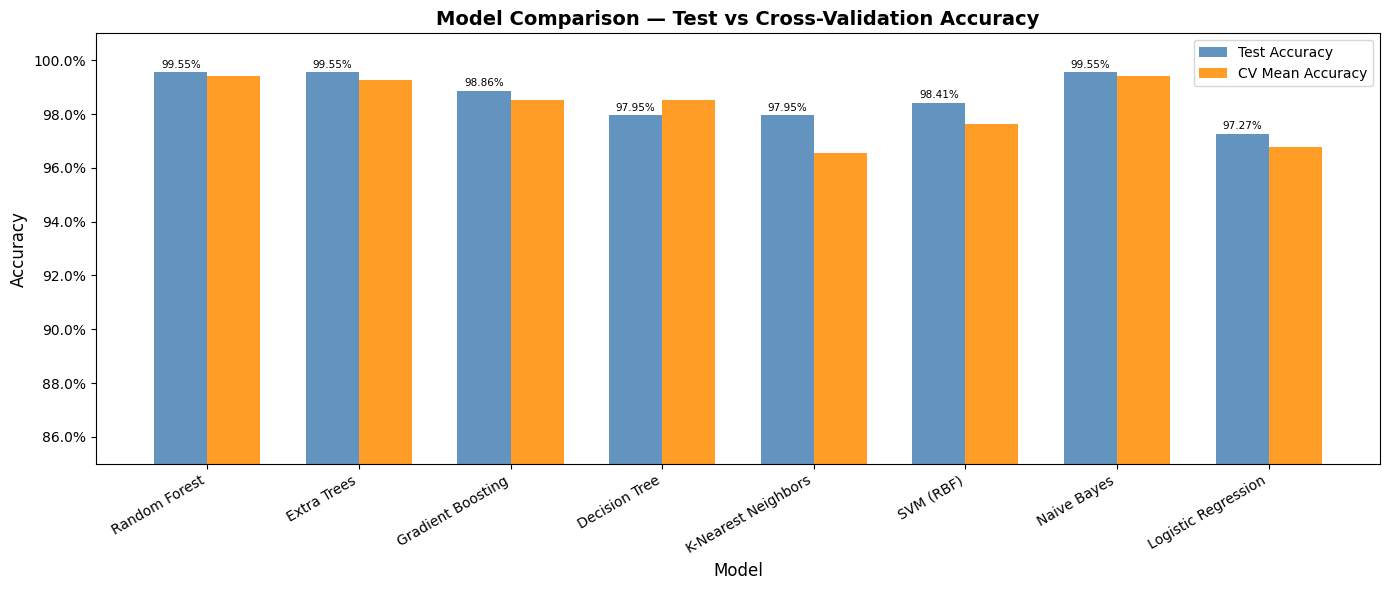

In [ ]:
# Visual comparison of model accuracies
names  = list(results.keys())
test_accs  = [results[n]['test_acc']  for n in names]
cv_means   = [results[n]['cv_mean']   for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, cv_means,  width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison — Test vs Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##Select Best Model & Fine-Tune

In [ ]:
# Identify best model by test accuracy
best_name = max(results, key=lambda n: results[n]['test_acc'])
best_info = results[best_name]

print(f' Best Model: {best_name}')
print(f'   Test Accuracy : {best_info["test_acc"]:.4f} ({best_info["test_acc"]*100:.2f}%)')
print(f'   CV Mean       : {best_info["cv_mean"]:.4f} ± {best_info["cv_std"]:.4f}')

 Best Model: Random Forest
   Test Accuracy : 0.9955 (99.55%)
   CV Mean       : 0.9943 ± 0.0054


In [ ]:
# Fine-tune Random Forest (usually the winner) with GridSearchCV
# (This targets RF; adjust if another model wins)
print(' Fine-tuning Random Forest with GridSearchCV...')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_tuned = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_tuned.fit(X_train, y_train)

print(f'\nBest Params : {rf_tuned.best_params_}')
print(f'Best CV Score: {rf_tuned.best_score_:.4f}')

 Fine-tuning Random Forest with GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.9960


In [ ]:
# Evaluate fine-tuned model
final_model = rf_tuned.best_estimator_
y_pred = final_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f'Final Model Test Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Final Model Test Accuracy: 0.9955 (99.55%)

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange  

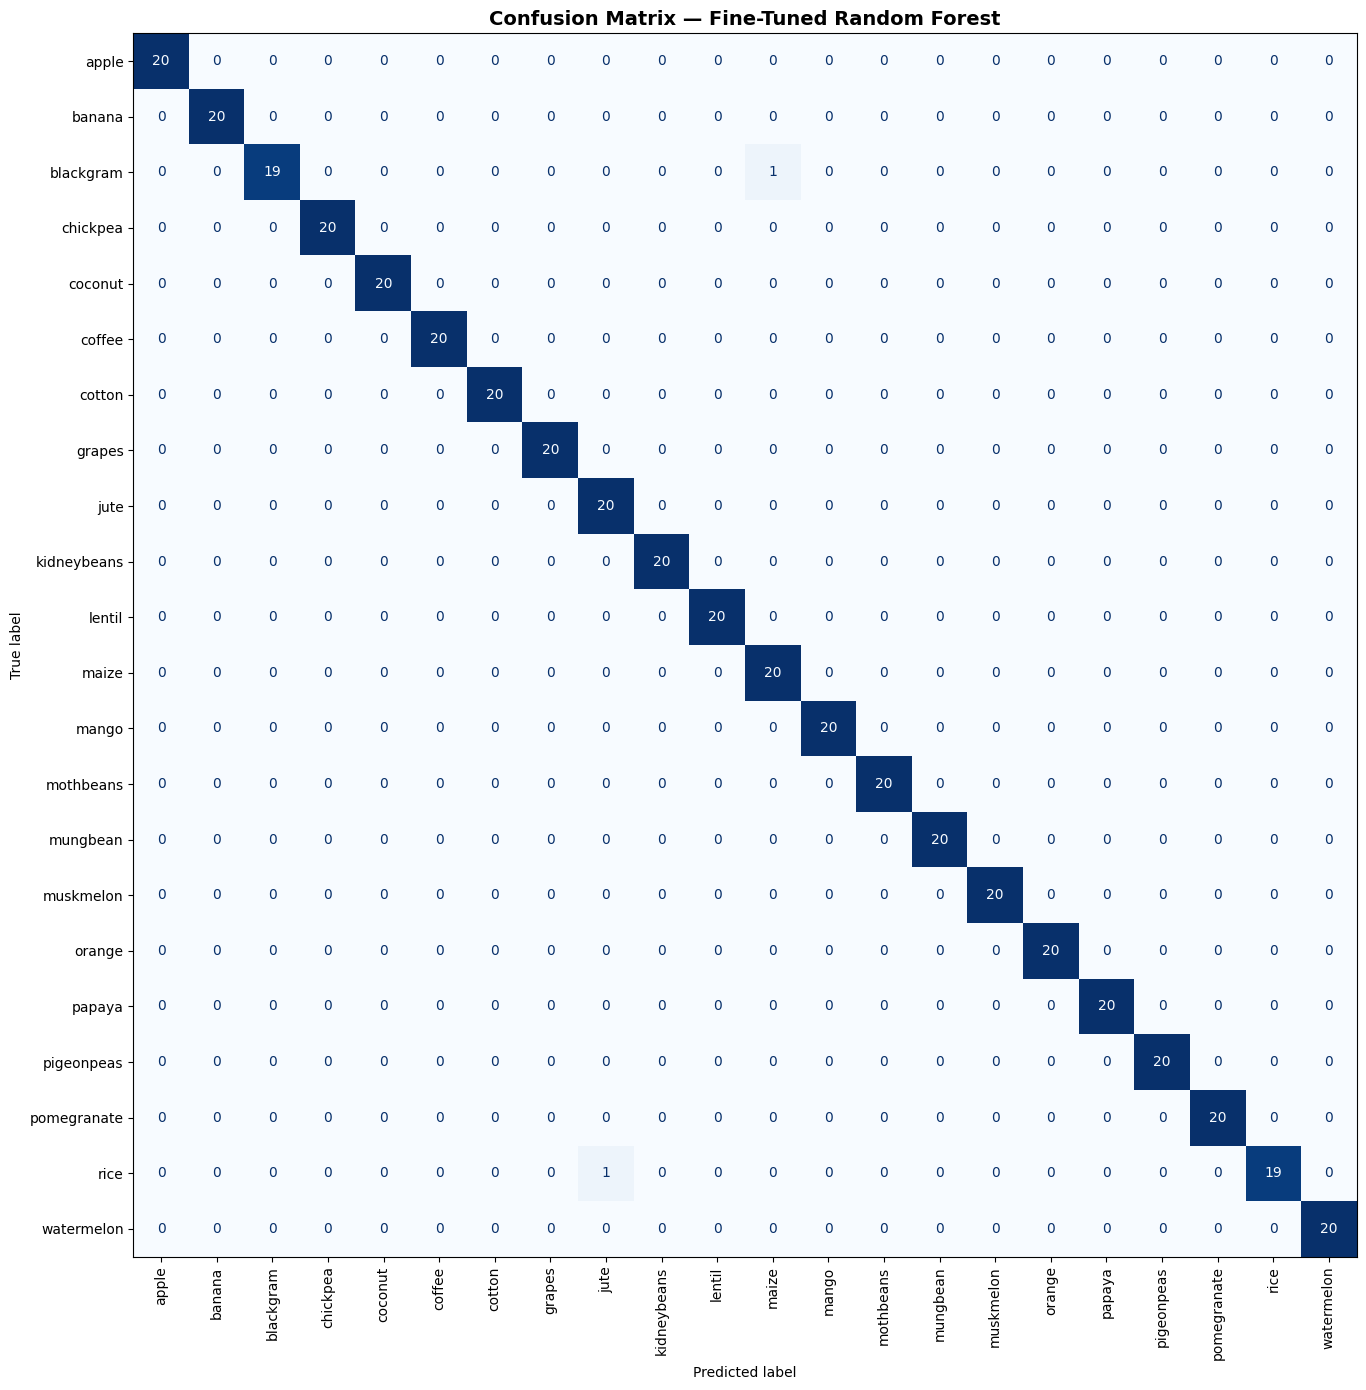

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation='vertical')
ax.set_title('Confusion Matrix — Fine-Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

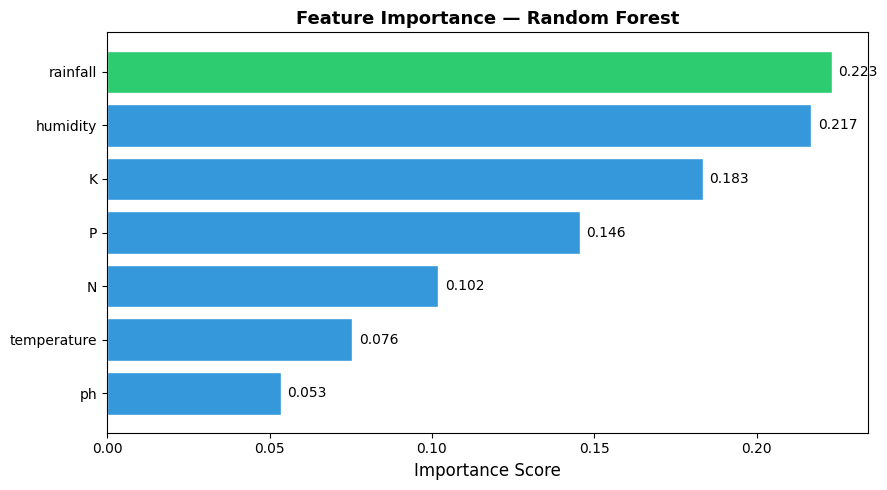

In [ ]:
# Feature importance
importances = final_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##Export Model Files

In [ ]:
# Create export directory
os.makedirs('crop_model_export', exist_ok=True)

# 1. Save model
joblib.dump(final_model, 'crop_model_export/crop_model.pkl')
print('Model saved: crop_model.pkl')

# 2. Save scaler (used by some models)
joblib.dump(scaler, 'crop_model_export/scaler.pkl')
print('Scaler saved: scaler.pkl')

# 3. Save label encoder
joblib.dump(le, 'crop_model_export/label_encoder.pkl')
print('Label encoder saved: label_encoder.pkl')

# 4. Save metadata JSON (used by frontend/Flask)
metadata = {
    'model_name': 'Random Forest (Fine-Tuned)',
    'accuracy': round(final_acc, 4),
    'features': features,
    'classes': list(le.classes_),
    'label_mapping': label_mapping,
    'best_params': rf_tuned.best_params_
}
with open('crop_model_export/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata saved: metadata.json')

print(f'\n All files saved in crop_model_export/')
print(f'   Final Accuracy: {final_acc*100:.2f}%')

Model saved: crop_model.pkl
Scaler saved: scaler.pkl
Label encoder saved: label_encoder.pkl
Metadata saved: metadata.json

 All files saved in crop_model_export/
   Final Accuracy: 99.55%


In [ ]:
# Zip and download model files
import shutil
shutil.make_archive('crop_model_export', 'zip', 'crop_model_export')
print(' Zipped: crop_model_export.zip')

# Download in Google Colab
try:
    from google.colab import files
    files.download('crop_model_export.zip')
    print(' Downloading crop_model_export.zip ...')
except:
    print('ℹ Not in Colab — files are in the current directory.')

 Zipped: crop_model_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Test Prediction (Sanity Check)

In [ ]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """Predict the best crop given soil & weather conditions."""
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    prediction = final_model.predict(input_data)[0]
    probabilities = final_model.predict_proba(input_data)[0]
    top3_idx = probabilities.argsort()[-3:][::-1]

    crop = le.inverse_transform([prediction])[0]
    confidence = probabilities[prediction] * 100

    print(f' Recommended Crop : {crop.upper()}')
    print(f' Confidence       : {confidence:.1f}%')
    print('\n Top 3 Recommendations:')
    for i, idx in enumerate(top3_idx, 1):
        name = le.inverse_transform([idx])[0]
        prob = probabilities[idx] * 100
        print(f'  {i}. {name:<15} {prob:.1f}%')
    return crop

# Example: Rice-like conditions
print('=== Test Prediction 1: Rice Conditions ===')
predict_crop(N=90, P=42, K=43, temperature=21, humidity=82, ph=6.5, rainfall=210)

print('\n=== Test Prediction 2: Maize Conditions ===')
predict_crop(N=20, P=30, K=10, temperature=27, humidity=65, ph=6.0, rainfall=90)

=== Test Prediction 1: Rice Conditions ===
 Recommended Crop : RICE
 Confidence       : 91.9%

 Top 3 Recommendations:
  1. rice            91.9%
  2. jute            6.4%
  3. pomegranate     1.4%

=== Test Prediction 2: Maize Conditions ===
 Recommended Crop : ORANGE
 Confidence       : 29.8%

 Top 3 Recommendations:
  1. orange          29.8%
  2. mango           26.3%
  3. pigeonpeas      17.5%


'orange'

##  Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Data loading & EDA | ✅ |
| 2 | Preprocessing & encoding | ✅ |
| 3 | Train 8 classifiers | ✅ |
| 4 | Fine-tune best model (GridSearchCV) | ✅ |
| 5 | Evaluate & visualize | ✅ |
| 6 | Export model files (.pkl + .json) | ✅ |

### 📁 Exported Files
- `crop_model.pkl` — Trained ML model
- `scaler.pkl` — Feature scaler
- `label_encoder.pkl` — Label encoder
- `metadata.json` — Model info & class mapping

> **Next Step:** Use these exported files with the Flask API + Frontend provided separately.
